In [16]:
import pandas as pd

df = pd.read_pickle("../../../datasets/nurse/paper/all.pkl")

In [17]:
x = df.drop(columns=["Label", "Participant"])
y = df["Label"]

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [13]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train = df[df["Participant"] != "6D"]
test = df[df["Participant"] == "6D"]
groups = train["Participant"]
x_train = train.drop(columns=["Participant", "Label"])
y_train = train["Label"]
x_test = test.drop(columns=["Participant", "Label"])
y_test = test["Label"]

In [19]:
import xgboost as xgb

clf = xgb.XGBClassifier()
clf.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

F1 score: 1.0000


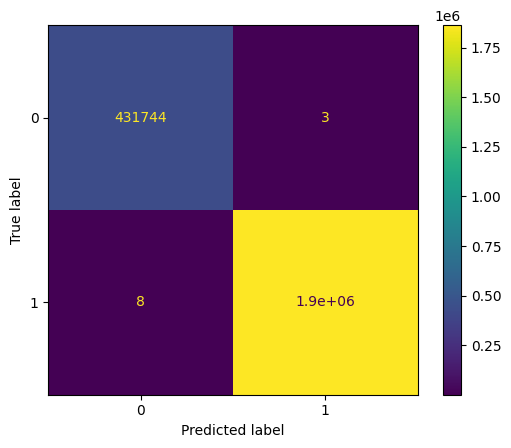

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, confusion_matrix

y_pred = clf.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()